# Functions and load dataset

### Mueller

In [1]:
from scipy.linalg import lstsq
import numpy as np
import pandas as pd
from tqdm import tqdm

def fit_pixels(x_train,y_train):
    M_array = np.zeros((x_train.shape[1],x_train.shape[2],3))
    for i in range(x_train.shape[1]):
        for j in range(x_train.shape[2]):
            x_pixel = x_train[:,i,j]
            M_array[i,j] = lstsq(y_train,x_pixel)[0]
            
    return M_array

def solve_S(x_test,M_array):
    
    S_array = np.zeros((x_test.shape[0],3))
    for i in range(x_test.shape[0]):
        S_array[i] = lstsq(M_array.reshape(-1,3),x_test[i].reshape(-1))[0]
    
    return S_array    



In [2]:
n_alpha=36
n_beta=36
n_insert=0
alpha_array=np.linspace(0,90,n_alpha+1)[:-1]
beta_array=np.linspace(0,180,n_beta+1)[:-1]

flat_x=np.zeros((n_alpha*(n_insert+1),n_beta*(n_insert+1),40*40),dtype=np.float32)
flat_y=np.zeros((n_alpha*(n_insert+1),n_beta*(n_insert+1),3),dtype=np.float32)

for i in tqdm(range(n_alpha)):
    for j in range(n_beta):
        cur_file=np.load("./training_set_processed/alpha%.2f_beta%.2f.npz"%(alpha_array[i],beta_array[j]))
        flat_x[i*(n_insert+1):(i+1)*(n_insert+1),j*(n_insert+1):(j+1)*(n_insert+1)]=cur_file["arr_0"]
        flat_y[i*(n_insert+1):(i+1)*(n_insert+1),j*(n_insert+1):(j+1)*(n_insert+1)]=cur_file["arr_1"]
flat_x=flat_x.reshape(-1,40*40)
flat_y=flat_y.reshape(-1,3)

x_train=flat_x.reshape(-1,40,40)
y_train=flat_y

100%|██████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 46.61it/s]


In [3]:
fo=np.load("./val_set/data_processed.npz")
x_val=fo["arr_0"].reshape(-1,40,40)
y_val=fo["arr_1"]

fo=np.load("./test_set/data_processed.npz")
x_test=fo["arr_0"].reshape(-1,40,40)
y_test=fo["arr_1"]

M_array = fit_pixels(x_train,y_train)
y_pred_M = solve_S(x_test,M_array)
print("MAE Mueller")
np.mean(np.abs(y_test-y_pred_M),0)

MAE Mueller


array([0.13885665, 0.1227508 , 0.12261086])

### CNN

In [4]:
import torch
print("Using torch", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

import numpy as np
from tqdm import tqdm

print("Loading training set")
n_alpha=36
n_beta=36
n_insert=0
alpha_array=np.linspace(0,90,n_alpha+1)[:-1]
beta_array=np.linspace(0,180,n_beta+1)[:-1]

flat_x=np.zeros((n_alpha*(n_insert+1),n_beta*(n_insert+1),40*40),dtype=np.float32)
flat_y=np.zeros((n_alpha*(n_insert+1),n_beta*(n_insert+1),3),dtype=np.float32)

for i in tqdm(range(n_alpha)):
    for j in range(n_beta):
        cur_file=np.load("./training_set_processed/alpha%.2f_beta%.2f.npz"%(alpha_array[i],beta_array[j]))
        flat_x[i*(n_insert+1):(i+1)*(n_insert+1),j*(n_insert+1):(j+1)*(n_insert+1)]=cur_file["arr_0"]
        flat_y[i*(n_insert+1):(i+1)*(n_insert+1),j*(n_insert+1):(j+1)*(n_insert+1)]=cur_file["arr_1"]
flat_x=flat_x.reshape(-1,40*40)
flat_y=flat_y.reshape(-1,3)

x_train=torch.from_numpy(flat_x.reshape(-1,1,40,40)).to(device)
y_train=torch.from_numpy(flat_y).to(device)
print("Loading validation set")
fo=np.load("./val_set/data_processed.npz")
x_val=torch.from_numpy(fo["arr_0"].reshape(-1,1,40,40)).to(device)
y_val=torch.from_numpy(fo["arr_1"]).to(device)
print("Loading test set")
fo=np.load("./test_set/data_processed.npz")
x_test=torch.from_numpy(fo["arr_0"].reshape(-1,1,40,40)).to(device)
y_test=torch.from_numpy(fo["arr_1"]).to(device)

import torch.nn as nn

class Simple_CNN(nn.Module):
    def __init__(self,p):
        super().__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(1,16,5,1,2),                              
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16,32,3,1,1),     
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                
        )
        self.conv3 = nn.Sequential(         
            nn.Conv2d(32,64,3,1,1),     
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                
        )
        self.mlp = nn.Sequential(
            nn.Dropout(p=p),
            nn.Linear(5*5*64,1024),
            nn.ReLU(),
            nn.Linear(1024,1024),
            nn.ReLU(),
            nn.Linear(1024,3),
        )
        
    def forward(self, x):
        y = self.conv1(x)
        y = self.conv2(y)
        y = self.conv3(y)
        y = y.view(y.size(0), -1)       
        y = self.mlp(y)
        return y
    
model=torch.load("./ML_result/CNN_p=0.001_seed324.pt")
model=model.to(device)
with torch.no_grad():
    y_pred=model(x_test).to("cpu").numpy()
    y_real=y_test.to("cpu").numpy()
print("MAE of CNN")
print(np.mean(np.abs(y_pred-y_real),axis=0))

Using torch 2.0.1+cu118
Using device: cuda
Loading training set


100%|██████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 48.19it/s]


Loading validation set
Loading test set
MAE of CNN
[0.01240004 0.0103232  0.00930395]


# Summary

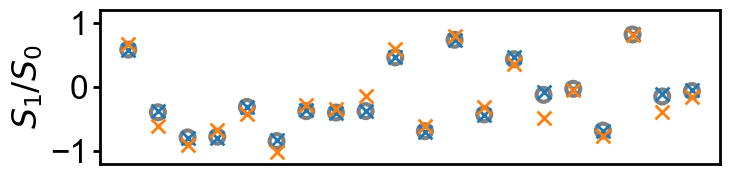

In [5]:
import matplotlib.pyplot as plt

seed = 324
np.random.seed(seed)
idx = np.arange(y_real.shape[0])
np.random.shuffle(idx)

plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(8, 2))

Si = 1
x=np.arange(20)
plt.scatter(x,y_real[idx[:20],Si-1],c="None",s=100,linewidths=3,edgecolor="gray",label="Ground truth")
plt.scatter(x,y_pred[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:blue",label="Mueller Calculus")
plt.scatter(x,y_pred_M[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:orange",label="CNN")

plt.ylim(-1.2,1.2)
plt.xticks([])
plt.yticks([-1,0,1])
plt.yticks(fontsize=24)
plt.ylabel(r"$S_%d/S_0$"%Si,fontsize=24)
#plt.legend(fontsize=18,ncol=2)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./S%d.svg"%Si,transparent=True,bbox_inches="tight")
plt.show()

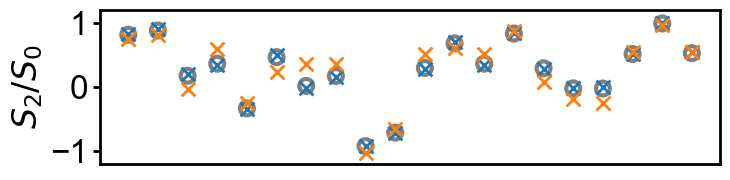

In [6]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(8, 2))

Si = 2
x=np.arange(20)
plt.scatter(x,y_real[idx[:20],Si-1],c="None",s=100,linewidths=3,edgecolor="gray",label="Ground truth")
plt.scatter(x,y_pred[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:blue",label="Mueller Calculus")
plt.scatter(x,y_pred_M[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:orange",label="CNN")

plt.ylim(-1.2,1.2)
plt.xticks([])
plt.yticks([-1,0,1])
plt.yticks(fontsize=24)
plt.ylabel(r"$S_%d/S_0$"%Si,fontsize=24)
#plt.legend(fontsize=18,ncol=2)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./S%d.svg"%Si,transparent=True,bbox_inches="tight")
plt.show()

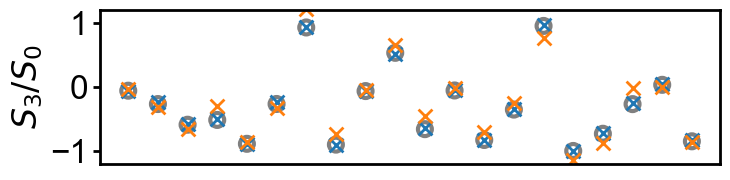

In [7]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(8, 2))

Si = 3
x=np.arange(20)
plt.scatter(x,y_real[idx[:20],Si-1],c="None",s=100,linewidths=3,edgecolor="gray",label="Ground truth")
plt.scatter(x,y_pred[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:blue",label="Mueller Calculus")
plt.scatter(x,y_pred_M[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:orange",label="CNN")

plt.ylim(-1.2,1.2)
plt.xticks([])
plt.yticks([-1,0,1])
plt.yticks(fontsize=24)
plt.ylabel(r"$S_%d/S_0$"%Si,fontsize=24)
#plt.legend(fontsize=18,ncol=2)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("./S%d.svg"%Si,transparent=True,bbox_inches="tight")
plt.show()

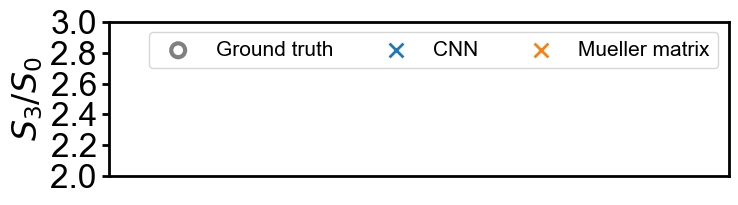

In [8]:
plt.rcParams['font.sans-serif'] = ['Arial']
plt.figure(figsize=(8, 2))

Si = 3
x=np.arange(20)
plt.scatter(x,y_real[idx[:20],Si-1],c="None",s=100,linewidths=3,edgecolor="gray",label="Ground truth")
plt.scatter(x,y_pred[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:blue",label="CNN")
plt.scatter(x,y_pred_M[idx[:20],Si-1],marker="x",s=100,linewidths=2,color="tab:orange",label="Mueller matrix")

plt.ylim(2,3)
plt.xticks([])
#plt.yticks([-1,0,1])
plt.yticks(fontsize=24)
plt.ylabel(r"$S_%d/S_0$"%Si,fontsize=24)
plt.legend(fontsize=15,ncol=3)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("legend.svg",transparent=True,bbox_inches="tight")
plt.show()

In [9]:
S1_MAE = np.array([0.13885665,0.14930146,0.11797609,0.10881595,0.09474341])
S2_MAE = np.array([0.1227508,0.12565173,0.10010389,0.0935098,0.06731382])
S3_MAE = np.array([0.12261086,0.09602955,0.05100296,0.03289654,0.13998226])

print("S1:",np.mean(S1_MAE),np.std(S1_MAE,ddof=1))
print("S2:",np.mean(S2_MAE),np.std(S2_MAE,ddof=1))
print("S3:",np.mean(S3_MAE),np.std(S3_MAE,ddof=1))

S1: 0.12193871199999999 0.022149663150813827
S2: 0.10186600799999998 0.023815541540751703
S3: 0.088504434 0.04573959078927445


# Dataset size

### matrix

In [10]:
n_alpha=36
n_beta=36
n_insert=0
alpha_array=np.linspace(0,90,n_alpha+1)[:-1]
beta_array=np.linspace(0,180,n_beta+1)[:-1]

flat_x=np.zeros((n_alpha*(n_insert+1),n_beta*(n_insert+1),40*40),dtype=np.float32)
flat_y=np.zeros((n_alpha*(n_insert+1),n_beta*(n_insert+1),3),dtype=np.float32)

for i in tqdm(range(n_alpha)):
    for j in range(n_beta):
        cur_file=np.load("./training_set_processed/alpha%.2f_beta%.2f.npz"%(alpha_array[i],beta_array[j]))
        flat_x[i*(n_insert+1):(i+1)*(n_insert+1),j*(n_insert+1):(j+1)*(n_insert+1)]=cur_file["arr_0"]
        flat_y[i*(n_insert+1):(i+1)*(n_insert+1),j*(n_insert+1):(j+1)*(n_insert+1)]=cur_file["arr_1"]
flat_x=flat_x.reshape(-1,40*40)
flat_y=flat_y.reshape(-1,3)

x_train=flat_x.reshape(-1,40,40)
y_train=flat_y

fo=np.load("./val_set/data_processed.npz")
x_val=fo["arr_0"].reshape(-1,40,40)
y_val=fo["arr_1"]

fo=np.load("./test_set/data_processed.npz")
x_test=fo["arr_0"].reshape(-1,40,40)
y_test=fo["arr_1"]


100%|██████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 47.47it/s]


In [11]:
seed = 1222
np.random.seed(seed)
idx = np.arange(x_train.shape[0])
np.random.shuffle(idx)

train_ratio = [0.01,0.02,0.04,0.07,0.1,
               0.15,0.2,0.3,0.4,0.6,0.8,1]
MEA_array = np.zeros((len(train_ratio),3))
train_size = np.zeros(len(train_ratio),dtype=np.int32)
true_M = fit_pixels(x_train,y_train)
fitting_MAE = np.zeros((len(train_ratio),3))
train_MAE = np.zeros(len(train_ratio))

for i in range(len(train_ratio)):
    end_idx = round(x_train.shape[0]*train_ratio[i])-1
    train_size[i] = end_idx+1
    M_array = fit_pixels(x_train[idx[:end_idx]],y_train[idx[:end_idx]])
    fitting_MAE[i] = np.mean(np.mean(np.abs(true_M - M_array),0),0)
    y_pred = solve_S(x_train[idx[:end_idx]],M_array)
    train_MAE[i] = np.mean(np.abs(y_train[idx[:end_idx]]-y_pred))
    y_pred = solve_S(x_test,M_array)
    MEA_array[i] = np.mean(np.abs(y_test-y_pred),0)

CNN_MAE = np.zeros(len(train_ratio))
CNN_MAE_train = np.zeros(len(train_ratio))
for i in range(len(train_ratio)):
    cur_table = pd.read_csv("../20240308_film2_36point/ML_result/change_size_ratio%.2f.csv"%train_ratio[i])
    min_idx = np.argmin(cur_table["validation_loss"].values)
    CNN_MAE[i] = np.mean(cur_table.iloc[min_idx,4:].values)
    CNN_MAE_train[i] = cur_table.iloc[min_idx,1]

array([0.16649964, 0.11940592, 0.06276695, 0.05319483, 0.0406057 ,
       0.02680099, 0.02035   , 0.01297972, 0.01189078, 0.01075081,
       0.0104835 , 0.01041062])

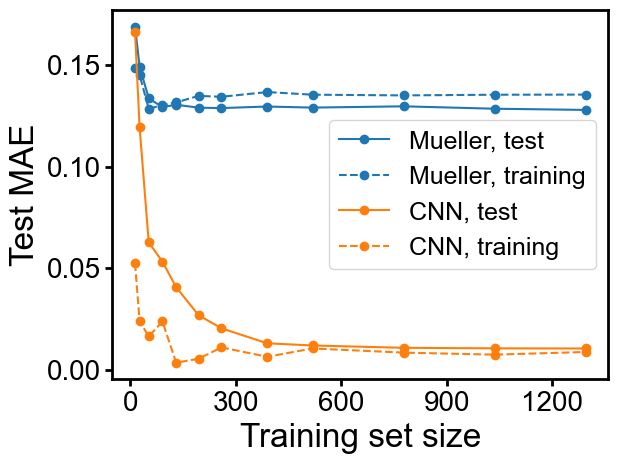

In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial']

#for i in range(3):
#    plt.plot(train_ratio,MEA_array[:,i],"-o")

plt.plot(train_size,np.mean(MEA_array,1),"o-",color="tab:blue",label="Mueller, test")
plt.plot(train_size,train_MAE,"o--",color="tab:blue",label="Mueller, training")

plt.plot(train_size,CNN_MAE,"o-",color="tab:orange",label="CNN, test")
plt.plot(train_size,CNN_MAE_train,"o--",color="tab:orange",label="CNN, training")


#plt.plot(train_size,train_MAE,"o-")

#plt.yscale("log")
plt.legend(fontsize=18)
plt.xticks([0,300,600,900,1200],fontsize=20)
plt.yticks([0,0.05,0.1,0.15],fontsize=20)
plt.ylabel("Test MAE",fontsize=24)
plt.xlabel("Training set size",fontsize=24)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)
plt.savefig("size_summary.svg",transparent=True,bbox_inches="tight")


CNN_MAE



array([[2.63679257e-02, 1.53722137e-02, 6.00933692e-03],
       [1.96898646e-02, 1.01648911e-02, 4.44681018e-03],
       [5.06476110e-03, 1.11299447e-02, 6.72911375e-03],
       [1.45896339e-03, 2.82177129e-03, 6.33203421e-03],
       [3.53944662e-03, 3.23961182e-03, 4.22462306e-03],
       [3.03217718e-03, 2.56441186e-03, 2.53490878e-03],
       [2.38508411e-03, 5.72198520e-04, 2.71962381e-03],
       [1.77763989e-03, 2.28071700e-03, 2.34664063e-03],
       [1.73330587e-03, 2.59833332e-03, 8.03761303e-04],
       [9.18206986e-04, 2.19823153e-03, 4.82861678e-04],
       [2.21730698e-03, 7.32966376e-04, 1.00859851e-03],
       [7.12274801e-05, 8.48473149e-05, 3.19748966e-05]])

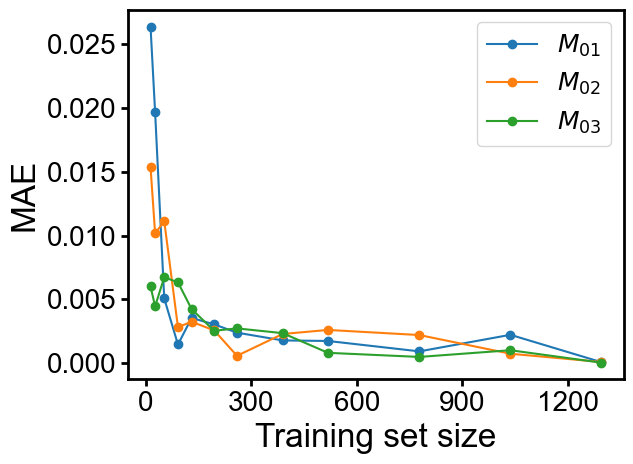

In [13]:
plt.rcParams['font.sans-serif'] = ['Arial']


for i in range(3):
    plt.plot(train_size,fitting_MAE[:,i],"o-",label="$M_{0%d}$"%(i+1))

plt.legend(fontsize=18)
plt.xticks([0,300,600,900,1200],fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel("MAE",fontsize=24)
plt.xlabel("Training set size",fontsize=24)

bwidth=2
plt.tick_params(which="major",width=bwidth,length=5)
plt.tick_params(which="minor",width=bwidth,length=3)
tk=plt.gca()
tk.spines["bottom"].set_linewidth(bwidth)
tk.spines["top"].set_linewidth(bwidth)
tk.spines["left"].set_linewidth(bwidth)
tk.spines["right"].set_linewidth(bwidth)

fitting_MAE